# SBI Binned SO Simple-Profile Pipeline Test

This notebook mirrors the active `SBI_binned_SO.ipynb` handoff into `sbi`, but replaces the expensive SO profile dataset with a deterministic analytic profile on the same 40-bin SO ell grid. The goal is a fast end-to-end check that the notebook plumbing works: build `theta_np`, `x_np`, apply the Gaussian beam to `x_gp`, construct the same `prepared` dictionary, train `NPE`, sample the posterior at `prepared["x_observed_gp"]`, save the samples, and run the same basic diagnostics.


In [1]:
from matplotlib.ticker import LinearLocator, MaxNLocator
import matplotlib.pyplot as plt
from pathlib import Path
import sys

import numpy as np

try:
    import torch
except ImportError:
    torch = None

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from sbi.analysis import pairplot
    from sbi.analysis import plot_summary
    from sbi.inference import NPE
except ImportError:
    pairplot = None
    plot_summary = None
    NPE = None


In [43]:
# Make the notebook work whether Jupyter is started from the repo root or SBI_analysis.
CWD = Path.cwd().resolve()
if CWD.name == "SBI_analysis":
    PROJECT_ROOT = CWD.parent
elif (CWD / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD
elif (CWD.parent / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

SBI_DIR = PROJECT_ROOT / "SBI_analysis"
if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

from sbi_utils import estimate_lightcone_sigma, prior_bounds

GAUSSIAN_BEAM_FWHM_ARCMIN = 2.0
ELL_MIN = 80
ELL_MAX = 7979
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

# Same 9-parameter Sobol prior used by SBI_binned_SO.ipynb.
SOBOL_PRIOR_BOUNDS = {
    "P0": [1.832524, 34.341221],
    "xc": [0.150011, 0.844503],
    "beta": [3.480627, 5.216611],
    "alpha_m_P0": [0.000312, 0.292251],
    "alpha_m_xc": [-0.099718, 0.099795],
    "alpha_m_beta": [-0.019935, 0.099767],
    "alpha_z_P0": [-1.363457, -0.228839],
    "alpha_z_xc": [0.147393, 1.314474],
    "alpha_z_beta": [0.083808, 0.745884],
}

param_names = list(SOBOL_PRIOR_BOUNDS)
prior_low_np, prior_high_np = prior_bounds({"prior": SOBOL_PRIOR_BOUNDS}, param_names)
prior_center_np = 0.5 * (prior_low_np + prior_high_np)
prior_half_width_np = 0.5 * (prior_high_np - prior_low_np)

# Keep the production fiducial marker. The simple profile treats this as the observed truth.
true_params = np.asarray([12.1, 0.407, 4.35, 0.154, 0.00265, 0.0493, -0.58, 0.731, 0.415], dtype=np.float32)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DEVICE: {DEVICE}")
print(f"parameters: {param_names}")


PROJECT_ROOT: \\wsl.localhost\myrootfs\home\cbllover\HalfDome
DEVICE: cpu
parameters: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']


## SO 40-Bin Grid

This is the same SO binning convention used in `SBI_binned_SO.ipynb`: ell 80 to 7979, 40 bins, and `2ell+1` weighting for bin centers.


In [22]:
SO_40_BIN_EDGES = np.r_[np.arange(80, 7881, 200), 7979].astype(np.float64)

DATAVECTOR_BINNING = {
    "enabled": True,
    "mode": "custom",
    "n_bins": 40,
    "ell_min": 80,
    "ell_max": 7979,
    "custom_edges": SO_40_BIN_EDGES,
    "statistic": "mean",
    "weighting": "2ell_plus_1",
}


def _bin_weights(ell_values, weighting="uniform"):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = str(weighting).lower()
    if weighting in {"uniform", "none", "flat"}:
        return np.ones_like(ell_values, dtype=np.float64)
    if weighting == "ell":
        return ell_values.astype(np.float64)
    if weighting in {"2ell_plus_1", "modes", "mode_count"}:
        return 2.0 * ell_values + 1.0
    raise ValueError("weighting must be 'uniform', 'ell', or '2ell_plus_1'")


def _weighted_center(lo, hi, weighting):
    ell_values = np.arange(int(lo), int(hi) + 1, dtype=np.float64)
    return float(np.average(ell_values, weights=_bin_weights(ell_values, weighting)))


bin_ell_min_np = SO_40_BIN_EDGES[:-1].copy()
bin_ell_max_np = SO_40_BIN_EDGES[1:].copy()
bin_ell_max_np[:-1] -= 1
ell_np = np.asarray(
    [_weighted_center(lo, hi, DATAVECTOR_BINNING["weighting"]) for lo, hi in zip(bin_ell_min_np, bin_ell_max_np)],
    dtype=np.float32,
)
bin_counts_np = (bin_ell_max_np - bin_ell_min_np + 1).astype(np.int64)

ell_unbinned_np = np.arange(ELL_MIN, ELL_MAX + 1, dtype=np.float32)
observed_bin_source_ell_np = ell_unbinned_np.copy()

BINNING_SUMMARY = {
    "enabled": True,
    "dataset_prebinned": False,
    "mode": DATAVECTOR_BINNING["mode"],
    "requested_n_bins": int(DATAVECTOR_BINNING["n_bins"]),
    "n_bins": int(ell_np.size),
    "statistic": DATAVECTOR_BINNING["statistic"],
    "weighting": DATAVECTOR_BINNING["weighting"],
    "observed_binning_statistic": DATAVECTOR_BINNING["statistic"],
    "observed_binning_weighting": DATAVECTOR_BINNING["weighting"],
    "observed_binning_label": "simple analytic SO bins",
    "ell_min": float(ell_np[0]),
    "ell_max": float(ell_np[-1]),
    "bin_counts": bin_counts_np,
    "bin_ell_min": bin_ell_min_np.astype(np.float32),
    "bin_ell_max": bin_ell_max_np.astype(np.float32),
}

print(f"active datavector: {ell_np.size} bins")
print(f"ell centers: {ell_np[0]:.1f}-{ell_np[-1]:.1f}")
print(f"observed source ell: {observed_bin_source_ell_np[0]:.0f}-{observed_bin_source_ell_np[-1]:.0f}")


active datavector: 40 bins
ell centers: 198.0-7929.6
observed source ell: 80-7979


## Simple Analytic Profile

The profile is intentionally simple and deterministic, but it still uses all 9 parameters. Each normalized parameter controls one smooth basis function in `log10(D_l)` space, so the SBI network sees the same parameter dimension as the production SO run while the simulator remains cheap.


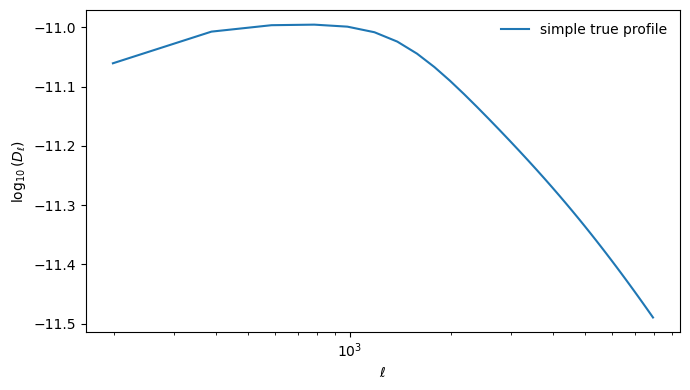

In [23]:
def normalized_theta(theta_values):
    theta_values = np.asarray(theta_values, dtype=np.float64)
    return (theta_values - prior_center_np) / prior_half_width_np


def simple_profile_basis(ell_values):
    ell_values = np.asarray(ell_values, dtype=np.float64).reshape(-1)
    u = np.log(ell_values / 1000.0)
    u = (u - u.mean()) / u.std()
    phase = (u - u.min()) / (u.max() - u.min())

    basis = np.vstack([
        np.ones_like(u),
        u,
        u**2 - np.mean(u**2),
        u**3 - np.mean(u**3),
        np.sin(1.25 * np.pi * phase),
        np.cos(1.75 * np.pi * phase),
        np.exp(-0.5 * ((u + 0.95) / 0.45)**2),
        np.exp(-0.5 * ((u - 0.05) / 0.55)**2),
        np.exp(-0.5 * ((u - 1.05) / 0.50)**2),
    ])

    for row in range(1, basis.shape[0]):
        scale = np.max(np.abs(basis[row]))
        if scale > 0:
            basis[row] /= scale
    return basis.astype(np.float64)


PROFILE_BASIS = simple_profile_basis(ell_np)
PROFILE_COEFFS = np.asarray([0.30, 0.22, -0.18, 0.13, 0.10, -0.08, 0.07, -0.06, 0.05], dtype=np.float64)


def simple_log10_dl_profile(theta_values, ell_values=ell_np):
    theta_values = np.asarray(theta_values, dtype=np.float64)
    was_1d = theta_values.ndim == 1
    theta_2d = theta_values[None, :] if was_1d else theta_values
    if theta_2d.shape[1] != len(param_names):
        raise ValueError(f"theta last dimension must be {len(param_names)}, got {theta_2d.shape[1]}")

    ell_values = np.asarray(ell_values, dtype=np.float64).reshape(-1)
    if ell_values.shape == ell_np.shape and np.allclose(ell_values, ell_np):
        basis = PROFILE_BASIS
    else:
        basis = simple_profile_basis(ell_values)

    z = normalized_theta(theta_2d)
    u = np.log(ell_values / 1000.0)
    u = (u - u.mean()) / u.std()
    base = -11.15 - 0.18 * u - 0.045 * (u**2 - np.mean(u**2))

    linear_part = (z * PROFILE_COEFFS[None, :]) @ basis
    mild_nonlinearity = 0.035 * (z[:, 0] * z[:, 1])[:, None] * basis[6][None, :]
    profile = base[None, :] + linear_part + mild_nonlinearity
    profile = np.ascontiguousarray(profile, dtype=np.float32)
    return profile[0] if was_1d else profile


plt.figure(figsize=(7, 4))
plt.plot(ell_np, simple_log10_dl_profile(true_params), label="simple true profile")
plt.xscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\log_{10}(D_\ell)$")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Build The Synthetic SBI Dataset

This cell creates the same arrays that the production notebook normally reads from disk. Row 0 is set to `true_params`, which also gives a controlled in-dataset observation for the dataset-size test cells.


In [24]:
N_SIMULATIONS = 2048
RANDOM_SEED = 42


def sample_prior_rows(n, seed=42):
    rng = np.random.default_rng(seed)
    try:
        from scipy.stats import qmc

        m = int(np.ceil(np.log2(int(n))))
        sampler = qmc.Sobol(d=len(param_names), scramble=True, seed=seed)
        unit = sampler.random_base2(m=m)[: int(n)]
    except Exception as exc:
        print(f"Falling back to NumPy uniform samples because scipy Sobol is unavailable: {exc}")
        unit = rng.random((int(n), len(param_names)))
    theta = prior_low_np[None, :] + unit * (prior_high_np - prior_low_np)[None, :]
    return np.ascontiguousarray(theta, dtype=np.float32)


theta_np = sample_prior_rows(N_SIMULATIONS, seed=RANDOM_SEED)
theta_np[0] = true_params

x_np = simple_log10_dl_profile(theta_np, ell_np)
x_y100_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y102_np = np.ascontiguousarray(x_np, dtype=np.float32)

sigma_log10_dl_np = estimate_lightcone_sigma(
    x_y100_np,
    x_y102_np,
    target="single_lightcone",
    sigma_floor=1.0e-4,
    scale=1.0,
).astype(np.float32)

ell_unbinned_np = np.ascontiguousarray(ell_np, dtype=np.float32)
x_unbinned_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y100_unbinned_np = np.ascontiguousarray(x_y100_np, dtype=np.float32)
x_y102_unbinned_np = np.ascontiguousarray(x_y102_np, dtype=np.float32)
sigma_log10_dl_unbinned_np = np.ascontiguousarray(sigma_log10_dl_np, dtype=np.float32)

print(f"theta_np: {theta_np.shape}  parameters: {param_names}")
print(f"x_np:     {x_np.shape}  data vector: simple analytic log10(D_l)")
print(f"ell_np:   {ell_np.shape}  ell range: {ell_np[0]:.0f}-{ell_np[-1]:.0f}")
print(f"sigma:    {sigma_log10_dl_np.shape}  median={np.median(sigma_log10_dl_np):.4g}")


theta_np: (2048, 9)  parameters: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
x_np:     (2048, 40)  data vector: simple analytic log10(D_l)
ell_np:   (40,)  ell range: 198-7930
sigma:    (40,)  median=0.0001


## Simulation Noise Off

This keeps the same no-noise setup as the active SO notebook.


In [25]:
SIMULATION_DATAVECTOR_NOISE = {
    "enabled": False,
    "mode": "none",
    "path": None,
}

x_clean_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y100_clean_np = np.ascontiguousarray(x_y100_np, dtype=np.float32)
x_y102_clean_np = np.ascontiguousarray(x_y102_np, dtype=np.float32)

simulation_noise_delta_np = np.zeros_like(x_clean_np, dtype=np.float32)
so_noise_sigma_dl_np = np.zeros(x_clean_np.shape[-1], dtype=np.float32)

x_np = x_clean_np
x_y100_np = x_y100_clean_np
x_y102_np = x_y102_clean_np

BINNING_SUMMARY["simulation_noise"] = {
    "enabled": False,
    "mode": "none",
    "path": None,
}

print("simulation datavector noise enabled:", SIMULATION_DATAVECTOR_NOISE["enabled"])
print("training x clean/no-noise shapes:", x_clean_np.shape, x_np.shape)
print("simulation noise delta log10(D_l):", f"rms={np.sqrt(np.mean(simulation_noise_delta_np**2)):.4g}", f"max_abs={np.max(np.abs(simulation_noise_delta_np)):.4g}")


simulation datavector noise enabled: False
training x clean/no-noise shapes: (2048, 40) (2048, 40)
simulation noise delta log10(D_l): rms=0 max_abs=0


## Gaussian Beam Preprocessing

Training and conditioning use the same Gaussian-beamed vectors as `SBI_binned_SO.ipynb`: `x_gp` and `x_observed_gp`.


In [26]:
def gaussian_beam_window(ells, fwhm_arcmin=1.6):
    fwhm_rad = np.deg2rad(fwhm_arcmin / 60.0)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))
    return np.exp(-0.5 * ells * (ells + 1.0) * sigma_rad**2)


def apply_gaussian_beam_to_log10_dl(log10_dl, ell, fwhm_arcmin=2.0):
    ell = np.asarray(ell, dtype=float)
    log10_dl = np.asarray(log10_dl, dtype=float)
    beam = gaussian_beam_window(ell, fwhm_arcmin=fwhm_arcmin)
    beam_log_factor = np.log10(np.maximum(beam**2, 1.0e-40))
    return log10_dl + beam_log_factor


USE_GAUSSIAN_BEAM = True
if USE_GAUSSIAN_BEAM:
    x_np_gp = np.ascontiguousarray(
        apply_gaussian_beam_to_log10_dl(x_np, ell_np, fwhm_arcmin=GAUSSIAN_BEAM_FWHM_ARCMIN),
        dtype=np.float32,
    )
else:
    x_np_gp = np.ascontiguousarray(x_np, dtype=np.float32)

print("using Gaussian beam preprocessing:", USE_GAUSSIAN_BEAM)
print("x_gp shape:", x_np_gp.shape)


using Gaussian beam preprocessing: True
x_gp shape: (2048, 40)


## Sobol Parameters

The names and bounds match the production SO notebook.


In [27]:
if pd is not None:
    sobol_parameters = pd.DataFrame(theta_np, columns=param_names)
    parameter_summary = pd.DataFrame(
        {
            "parameter": param_names,
            "prior_low": prior_low_np,
            "prior_high": prior_high_np,
            "sample_min": theta_np.min(axis=0),
            "sample_max": theta_np.max(axis=0),
            "truth": true_params,
        }
    )
    display(parameter_summary)
    display(sobol_parameters.head())
else:
    print("parameter, prior_low, prior_high, sample_min, sample_max, truth")
    for row in zip(param_names, prior_low_np, prior_high_np, theta_np.min(axis=0), theta_np.max(axis=0), true_params):
        print(row)


,parameter,prior_low,prior_high,sample_min,sample_max,truth
0,P0,1.832524,34.341221,1.841624,34.338890,12.10000
1,xc,0.150011,0.844503,0.150137,0.844455,0.40700
2,beta,3.480627,5.216611,3.481252,5.215869,4.35000
3,alpha_m_P0,0.000312,0.292251,0.000320,0.292205,0.15400
4,alpha_m_xc,-0.099718,0.099795,-0.099690,0.099726,0.00265
5,alpha_m_beta,-0.019935,0.099767,-0.019892,0.099728,0.04930
6,alpha_z_P0,-1.363457,-0.228839,-1.363075,-0.229229,-0.58000
7,alpha_z_xc,0.147393,1.314474,0.147510,1.314222,0.73100
8,alpha_z_beta,0.083808,0.745884,0.083960,0.745575,0.41500


,P0,xc,beta,alpha_m_P0,alpha_m_xc,alpha_m_beta,alpha_z_P0,alpha_z_xc,alpha_z_beta
0,12.100000,0.407000,4.350000,0.154000,0.002650,0.049300,-0.580000,0.731000,0.415000
1,28.331751,0.283028,3.870168,0.268526,0.041406,-0.007456,-0.944183,0.280149,0.152040
2,19.004681,0.607408,4.648932,0.084275,0.085227,0.013503,-0.274292,0.466049,0.387445
3,9.166277,0.350511,4.099664,0.200152,-0.084036,0.044682,-1.250326,1.033642,0.501195
4,5.556665,0.532051,3.654493,0.153473,-0.072272,0.085513,-0.440902,0.657212,0.311583


## Torch Tensors For `sbi`

This is intentionally the same `prepared` dictionary shape used by the SO notebook.


In [28]:
if torch is None:
    theta = theta_np
    x = x_np
    x_clean = x_clean_np
    x_simulation_noise_delta = simulation_noise_delta_np
    x_gp = x_np_gp
    x_y100 = x_y100_np
    x_y102 = x_y102_np
    ell = ell_np
    sigma_log10_dl = sigma_log10_dl_np
    prior_low = prior_low_np.astype(np.float32, copy=False)
    prior_high = prior_high_np.astype(np.float32, copy=False)
    print("Torch is not installed in this kernel; using NumPy arrays for now.")
else:
    theta_cpu = torch.from_numpy(theta_np)
    x_cpu = torch.from_numpy(x_np)
    x_clean_cpu = torch.from_numpy(x_clean_np)
    x_simulation_noise_delta_cpu = torch.from_numpy(simulation_noise_delta_np)
    x_cpu_gp = torch.from_numpy(x_np_gp)
    x_y100_cpu = torch.from_numpy(x_y100_np)
    x_y102_cpu = torch.from_numpy(x_y102_np)
    ell_cpu = torch.from_numpy(ell_np)
    sigma_log10_dl_cpu = torch.from_numpy(sigma_log10_dl_np)
    prior_low_cpu = torch.from_numpy(prior_low_np.astype(np.float32, copy=False))
    prior_high_cpu = torch.from_numpy(prior_high_np.astype(np.float32, copy=False))

    theta = theta_cpu.to(DEVICE, non_blocking=True)
    x = x_cpu.to(DEVICE, non_blocking=True)
    x_clean = x_clean_cpu.to(DEVICE, non_blocking=True)
    x_simulation_noise_delta = x_simulation_noise_delta_cpu.to(DEVICE, non_blocking=True)
    x_gp = x_cpu_gp.to(DEVICE, non_blocking=True)
    x_y100 = x_y100_cpu.to(DEVICE, non_blocking=True)
    x_y102 = x_y102_cpu.to(DEVICE, non_blocking=True)
    ell = ell_cpu.to(DEVICE, non_blocking=True)
    sigma_log10_dl = sigma_log10_dl_cpu.to(DEVICE, non_blocking=True)
    prior_low = prior_low_cpu.to(DEVICE, non_blocking=True)
    prior_high = prior_high_cpu.to(DEVICE, non_blocking=True)

    print(theta.dtype, theta.device, theta.shape)
    print(x.dtype, x.device, x.shape)


torch.float32 cpu torch.Size([2048, 9])
torch.float32 cpu torch.Size([2048, 40])


In [29]:
if torch is None:
    prior = None
else:
    try:
        from sbi.utils import BoxUniform

        try:
            prior = BoxUniform(low=prior_low, high=prior_high, device=DEVICE)
        except TypeError:
            prior = BoxUniform(low=prior_low, high=prior_high)
    except ImportError:
        prior = None
        print("sbi is not available in this kernel; install/fix sbi and torch before training.")

prepared = {
    "theta": theta,
    "x": x,
    "x_clean": x_clean,
    "x_simulation_noise_delta": x_simulation_noise_delta,
    "x_gp": x_gp,
    "x_y100": x_y100,
    "x_y102": x_y102,
    "ell": ell,
    "sigma_log10_dl": sigma_log10_dl,
    "prior_low": prior_low,
    "prior_high": prior_high,
    "param_names": param_names,
    "prior": prior,
    "binning": BINNING_SUMMARY,
    "simulation_noise": SIMULATION_DATAVECTOR_NOISE,
    "noise_sigma_dl": so_noise_sigma_dl_np,
    "ell_unbinned": ell_unbinned_np,
    "theta_true": true_params,
}

prepared.keys()


dict_keys(['theta', 'x', 'x_clean', 'x_simulation_noise_delta', 'x_gp', 'x_y100', 'x_y102', 'ell', 'sigma_log10_dl', 'prior_low', 'prior_high', 'param_names', 'prior', 'binning', 'simulation_noise', 'noise_sigma_dl', 'ell_unbinned', 'theta_true'])

## Observed Fiducial Spectrum

The observed vector is generated from the same simple profile at `true_params`, then processed with the same Gaussian beam as the training vectors.


In [30]:
print("observed source ell:", observed_bin_source_ell_np.shape, observed_bin_source_ell_np[0], observed_bin_source_ell_np[-1])
print("active ell bins:", ell_np.shape, ell_np[0], ell_np[-1])

x_observed_log10_np = np.ascontiguousarray(simple_log10_dl_profile(true_params, ell_np), dtype=np.float32)
if x_observed_log10_np.shape != ell_np.shape:
    raise ValueError(f"Observed vector has shape {x_observed_log10_np.shape}, expected {ell_np.shape}.")

x_observed_np = np.ascontiguousarray(10.0**x_observed_log10_np, dtype=np.float32)
observed_noise_dl_np = np.zeros_like(x_observed_np, dtype=np.float32)

x_observed_gp_np = np.ascontiguousarray(
    apply_gaussian_beam_to_log10_dl(
        x_observed_log10_np,
        ell_np,
        fwhm_arcmin=GAUSSIAN_BEAM_FWHM_ARCMIN,
    ),
    dtype=np.float32,
)

x_obs = x_observed_log10_np
x_obs_gb = x_observed_gp_np
x_observed_no_noise_gp_np = x_observed_gp_np

print("observed source: simple analytic truth")
print("observed no-noise shape:", x_observed_log10_np.shape)
print("observed noise max:", float(np.max(np.abs(observed_noise_dl_np))))


observed source ell: (7900,) 80.0 7979.0
active ell bins: (40,) 198.01805 7929.605
observed source: simple analytic truth
observed no-noise shape: (40,)
observed noise max: 0.0


In [31]:
def to_torch_or_numpy(values):
    values = np.ascontiguousarray(values, dtype=np.float32)
    if torch is None:
        return values
    return torch.from_numpy(values).to(DEVICE, non_blocking=True)


prepared.update({
    "x_observed_log10": to_torch_or_numpy(x_observed_log10_np),
    "x_observed_gp": to_torch_or_numpy(x_observed_gp_np),
    "observed_noise_dl": observed_noise_dl_np,
    "observed_path": "simple_profile:true_params",
})

x_o = prepared["x_observed_gp"]

assert np.allclose(observed_noise_dl_np, 0.0)
assert np.asarray(x_obs_gb).shape == ell_np.shape


## Run SBI On The Simple SO No-Noise Dataset

The training call below is the same active pipeline as `SBI_binned_SO.ipynb`: train `NPE` on `prepared["theta"]` and `prepared["x_gp"]`, then condition on `prepared["x_observed_gp"]`. The defaults are intentionally small so this can be used as a code-path test.


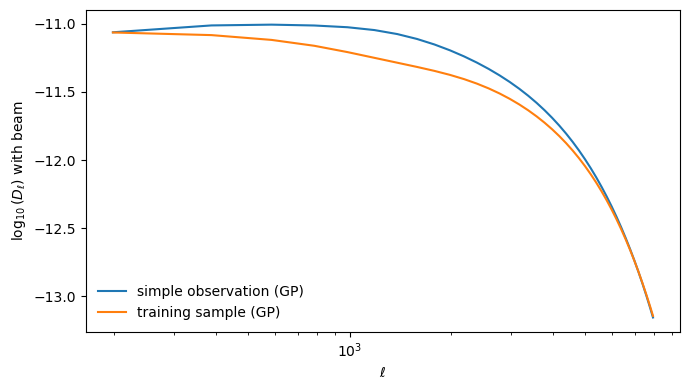

In [32]:
plt.figure(figsize=(7, 4))
plt.plot(ell_np, x_obs_gb, label="simple observation (GP)")
plt.plot(ell_np, np.asarray(prepared["x_gp"][3].detach().cpu() if hasattr(prepared["x_gp"], "detach") else prepared["x_gp"][4]), label="training sample (GP)")
plt.xscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\log_{10}(D_\ell)$ with beam")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [35]:
if torch is None or NPE is None or prepared["prior"] is None:
    raise RuntimeError("Install/fix torch and sbi before running the SBI training cells.")

seed = 42
num_main_posterior_samples = 100_000
stop_after_epochs = 30
density_estimator_name = "zuko_maf"

torch.manual_seed(seed)
np.random.seed(seed)

inference = NPE(prior=prepared["prior"], density_estimator=density_estimator_name)
density_estimator = inference.append_simulations(
    prepared["theta"],
    prepared["x_gp"],
).train(stop_after_epochs=stop_after_epochs)

x_o = prepared["x_observed_gp"]
posterior = inference.build_posterior(density_estimator)
samples = posterior.sample((num_main_posterior_samples,), x=x_o)


 Neural network successfully converged after 248 epochs.

  0%|          | 0/100000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=\\wsl.localhost\myrootfs\home\cbllover\HalfDome\SBI_analysis\sbi-logs\NPE_C\2026-07-06T14_51_58.979639' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


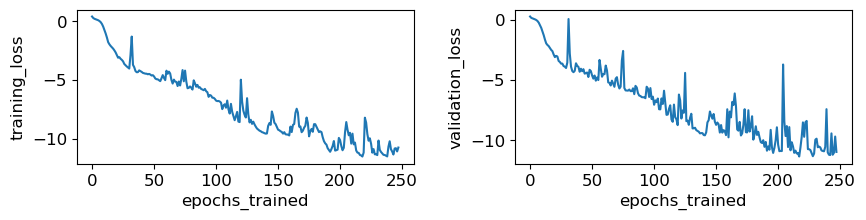

In [36]:
if plot_summary is not None:
    _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
    )
else:
    print("sbi.analysis.plot_summary is not available in this environment.")


In [ ]:
posterior_save_path = Path("outputs") / "posteriors" / "posterior_SO_simple_profile_binned40_gp_no_noise_NPE_zuko_maf.npy"
posterior_save_path.parent.mkdir(parents=True, exist_ok=True)
np.save(posterior_save_path, samples.detach().cpu().numpy() if hasattr(samples, "detach") else np.asarray(samples))
posterior_save_path


## Posterior Summary

For a quick code-path test, the important thing is that posterior sampling returns finite samples with the expected shape. The summary also compares against the known simple-profile truth.


In [37]:
posterior_np = samples.detach().cpu().numpy() if hasattr(samples, "detach") else np.asarray(samples)
param_names = list(prepared["param_names"])
true_values = np.asarray(prepared.get("theta_true", true_params), dtype=float).reshape(-1)

summary = pd.DataFrame({
    "parameter": param_names,
    "true": true_values,
    "mean": np.mean(posterior_np, axis=0),
    "median": np.median(posterior_np, axis=0),
    "std": np.std(posterior_np, axis=0),
    "q16": np.percentile(posterior_np, 16, axis=0),
    "q84": np.percentile(posterior_np, 84, axis=0),
    "q2.5": np.percentile(posterior_np, 2.5, axis=0),
    "q97.5": np.percentile(posterior_np, 97.5, axis=0),
}) if pd is not None else None

if summary is not None:
    summary["median - true"] = summary["median"] - summary["true"]
    summary["mean - true"] = summary["mean"] - summary["true"]
    summary["pull"] = (summary["median"] - summary["true"]) / summary["std"]
    summary["true in 68%"] = (summary["true"] >= summary["q16"]) & (summary["true"] <= summary["q84"])
    summary["true in 95%"] = (summary["true"] >= summary["q2.5"]) & (summary["true"] <= summary["q97.5"])

    pretty = summary.copy()
    pretty["68% interval"] = pretty.apply(lambda r: f"[{r['q16']:.4g}, {r['q84']:.4g}]", axis=1)
    pretty["95% interval"] = pretty.apply(lambda r: f"[{r['q2.5']:.4g}, {r['q97.5']:.4g}]", axis=1)
    pretty = pretty[[
        "parameter",
        "true",
        "mean",
        "median",
        "std",
        "68% interval",
        "95% interval",
        "median - true",
        "pull",
        "true in 68%",
        "true in 95%",
    ]]
    display(
        pretty.style
        .format({
            "true": "{:.5g}",
            "mean": "{:.5g}",
            "median": "{:.5g}",
            "std": "{:.5g}",
            "median - true": "{:+.5g}",
            "pull": "{:+.2f}",
        })
        .background_gradient(subset=["pull"], cmap="coolwarm", vmin=-3, vmax=3)
    )
else:
    print("posterior shape:", posterior_np.shape)
    print("posterior finite:", bool(np.all(np.isfinite(posterior_np))))


,parameter,true,mean,median,std,68% interval,95% interval,median - true,pull,true in 68%,true in 95%
0,P0,12.1,12.348,12.423,1.1876,"[10.98, 13.6]","[10.13, 14.44]",+0.32255,+0.27,True,True
1,xc,0.407,0.43409,0.43536,0.11831,"[0.3102, 0.5557]","[0.2043, 0.6592]",+0.028361,+0.24,True,True
2,beta,4.35,4.3114,4.308,0.38048,"[3.907, 4.713]","[3.598, 5.053]",-0.04199,-0.11,True,True
3,alpha_m_P0,0.154,0.14166,0.14124,0.066603,"[0.06979, 0.2128]","[0.01828, 0.2695]",-0.012758,-0.19,True,True
4,alpha_m_xc,0.00265,0.0080891,0.0082289,0.046308,"[-0.04271, 0.0596]","[-0.07797, 0.09075]",+0.0055789,+0.12,True,True
5,alpha_m_beta,0.0493,0.051371,0.051787,0.020225,"[0.03089, 0.07212]","[0.01055, 0.0895]",+0.002487,+0.12,True,True
6,alpha_z_P0,-0.58,-0.67917,-0.6698,0.2235,"[-0.9096, -0.444]","[-1.14, -0.2838]",-0.089801,-0.40,True,True
7,alpha_z_xc,0.731,0.77345,0.77458,0.20488,"[0.5612, 0.9841]","[0.3788, 1.17]",+0.043581,+0.21,True,True
8,alpha_z_beta,0.415,0.40114,0.39046,0.18062,"[0.1985, 0.6144]","[0.1042, 0.7234]",-0.024536,-0.14,True,True


In [ ]:
true_params = np.array([
    18.1,
    0.497,
    4.35,
    0.154,
    -0.00865,
    0.0393,
    -0.758,
    0.731,
    0.415,
], dtype=float)[:n_params]


Removed no burn in


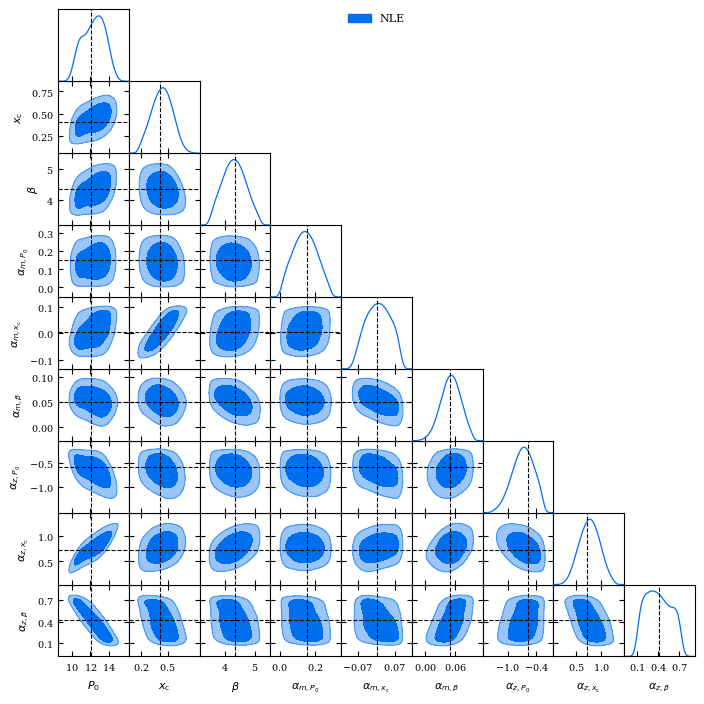

In [46]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

truth_markers = {
    names[i]: true_params[i]
    for i in range(n_params)
}

# Convert posterior samples
samples_np = samples.detach().cpu().numpy() if isinstance(samples, torch.Tensor) else np.asarray(samples)
n_params = samples_np.shape[1]

# A&A-compatible parameter names and labels
names = [f"p{i}" for i in range(n_params)]

base_labels = [
    r"P_0",
    r"x_{\rm c}",
    r"\beta",
    r"\alpha_{m,P_0}",
    r"\alpha_{m,x_{\rm c}}",
    r"\alpha_{m,\beta}",
    r"\alpha_{z,P_0}",
    r"\alpha_{z,x_{\rm c}}",
    r"\alpha_{z,\beta}",
]
labels = base_labels[:n_params]

gd_samples = MCSamples(
    samples=samples_np,
    names=names,
    labels=labels,
    label=r"NLE",
)

# Settings for non-Gaussian SBI posteriors
gd_samples.updateSettings({
    "smooth_scale_1D": 0.3,
    "smooth_scale_2D": 0.3,
    "fine_bins": 2048,
    "fine_bins_2D": 1024,
})

# A&A figure style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

double_col_width_in = 18.0 / 2.54

g = plots.get_subplot_plotter(width_inch=double_col_width_in)

g.settings.axes_fontsize = 7
g.settings.lab_fontsize = 8
g.settings.legend_fontsize = 8
g.settings.alpha_filled_add = 0.75
g.settings.linewidth = 1.0
g.settings.num_plot_contours = 2
g.settings.figure_legend_frame = False
g.settings.scaling = False

g.triangle_plot(
    [gd_samples],
    params=names,
    filled=True,
    legend_labels=[r"NLE"],
    contour_lws=[0.9],
    diag1d_kwargs={"linewidth": 1.0},
    markers=truth_markers,
    marker_args={
        "color": "black",
        "ls": "--",
        "lw": 0.8,
    },
)

plt.savefig("triangle_NLE_AA.png", dpi=300)
# plt.savefig("triangle_NLE_AA.pdf", dpi=300)
plt.show()

## Optional Dataset-Size Test

This mirrors the dataset-size loop from `SBI_binned_SO.ipynb`, but with much smaller defaults. Leave `RUN_DATASET_SIZE_TESTS = False` unless you specifically want to exercise repeated training.


In [ ]:
RUN_DATASET_SIZE_TESTS = False

if RUN_DATASET_SIZE_TESTS:
    if torch is None or NPE is None or prepared["prior"] is None:
        raise RuntimeError("Install/fix torch and sbi before running the dataset-size tests.")

    num_posterior_samples = 5_000
    size_stop_after_epochs = 6
    seed = 42

    theta_all = prepared["theta"][1:]
    x_all = prepared["x_gp"][1:]
    theta_all = torch.as_tensor(theta_all, dtype=torch.float32, device=DEVICE)
    x_all = torch.as_tensor(x_all, dtype=torch.float32, device=DEVICE)

    x_o = torch.as_tensor(prepared["x_gp"][0], dtype=torch.float32, device=DEVICE)
    theta_true_np = np.asarray(
        prepared["theta"][0].detach().cpu() if hasattr(prepared["theta"], "detach") else prepared["theta"][0],
        dtype=float,
    )

    dataset_lengths = [256, 512, 1024, len(theta_all)]
    dataset_lengths = sorted({n for n in dataset_lengths if n <= len(theta_all)})
    print("Dataset lengths:", dataset_lengths)

    prior_width = (prior_high_np - prior_low_np).astype(float)
    results = {}
    summary_rows = []

    for ntrain in dataset_lengths:
        print(f"\nTraining NPE with n = {ntrain}")
        torch.manual_seed(seed)
        np.random.seed(seed)

        inference = NPE(prior=prepared["prior"], density_estimator="zuko_maf")
        density_estimator = inference.append_simulations(
            theta_all[:ntrain],
            x_all[:ntrain],
        ).train(stop_after_epochs=size_stop_after_epochs)

        posterior = inference.build_posterior(density_estimator)
        with torch.no_grad():
            size_samples = posterior.sample((num_posterior_samples,), x=x_o)

        samples_np = size_samples.detach().cpu().numpy()
        mean = samples_np.mean(axis=0)
        std = samples_np.std(axis=0)
        median = np.median(samples_np, axis=0)
        q16 = np.percentile(samples_np, 16, axis=0)
        q84 = np.percentile(samples_np, 84, axis=0)
        width_over_prior = std / prior_width
        pull = (mean - theta_true_np) / std

        results[ntrain] = {
            "posterior": posterior,
            "density_estimator": density_estimator,
            "samples": samples_np,
            "mean": mean,
            "std": std,
            "median": median,
            "q16": q16,
            "q84": q84,
            "width_over_prior": width_over_prior,
            "pull": pull,
        }

        for j, name in enumerate(param_names):
            summary_rows.append({
                "ntrain": ntrain,
                "parameter": name,
                "mean": mean[j],
                "median": median[j],
                "std": std[j],
                "q16": q16[j],
                "q84": q84[j],
                "prior_width": prior_width[j],
                "std_over_prior_width": width_over_prior[j],
                "pull": pull[j],
            })

    summary_df = pd.DataFrame(summary_rows) if pd is not None else summary_rows
    display(summary_df) if pd is not None else print(summary_df)
else:
    print("Dataset-size test skipped. Set RUN_DATASET_SIZE_TESTS = True to run it.")
